## Phase 1: Data Understanding & Preparation
**Objective:** Load the dataset, inspect its structure, handle missing values, remove duplicates, eliminate unique identifiers to prevent data leakage, and prepare the target variable for machine learning.

### 1.1 Loading Libraries and Dataset

In [68]:
# Import essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the Telco Customer Churn dataset from the local directory
df = pd.read_csv('data/TelcoCustomerChurn.csv')

print("Initial Dataset Shape:", df.shape)
print("\nFirst 3 rows of the dataset:")
display(df.head(3))

Initial Dataset Shape: (7043, 21)

First 3 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### 1.2 Inspecting Dataset Structure and Data Types

In [69]:
# Inspect data types to verify correct typing (e.g., numeric fields vs text objects)
print("--- Data Types & Structure ---")
print(df.dtypes)

--- Data Types & Structure ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### 1.3 Handling Missing Values (TotalCharges Cleaning)

In [70]:
# The 'TotalCharges' column contains blank whitespace strings (' ') hidden as text.
# We convert them to numeric values using errors='coerce' to safely transform blanks into NaNs.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing Values Found:")
print(df.isnull().sum())

# Drop rows with missing TotalCharges (representing a negligible fraction of the dataset)
df.dropna(subset=['TotalCharges'], inplace=True)
print("\nShape after dropping missing values:", df.shape)

Missing Values Found:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Shape after dropping missing values: (7032, 21)


### 1.4 Removing Duplicates and Unique Identifiers (Preventing Data Leakage)

In [71]:
# Check and remove any duplicate rows to ensure data integrity
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows successfully removed.")
else:
    print("No duplicate rows found.")

# Drop 'customerID' as it is a unique identifier for each individual record.
# Keeping unique identifiers causes tree-based and linear models to memorize instances rather than learn generalizable behavioral patterns (preventing data leakage and overfitting).
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    print("Column 'customerID' dropped successfully.")

print("\nColumns remaining in dataset:", df.columns.tolist())

Number of duplicate rows found: 0
No duplicate rows found.
Column 'customerID' dropped successfully.

Columns remaining in dataset: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 1.5 Target Variable Analysis and Encoding

In [72]:
# Analyze the proportion of churned vs retained customers to understand class distribution
print("Target Variable Value Counts (Proportions):")
print(df['Churn'].value_counts(normalize=True))

# Map the categorical target variable to binary numeric values ('Yes' -> 1, 'No' -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("\nData preparation complete. Dataset is ready for Exploratory Data Analysis.")

Target Variable Value Counts (Proportions):
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

Data preparation complete. Dataset is ready for Exploratory Data Analysis.


## Phase 2: Exploratory Data Analysis (EDA)
**Objective:** Visualize customer behavioral trends, numerical feature distributions, and categorical risk factors associated with customer churn.

### 2.1 Visualizing Target Class Distribution

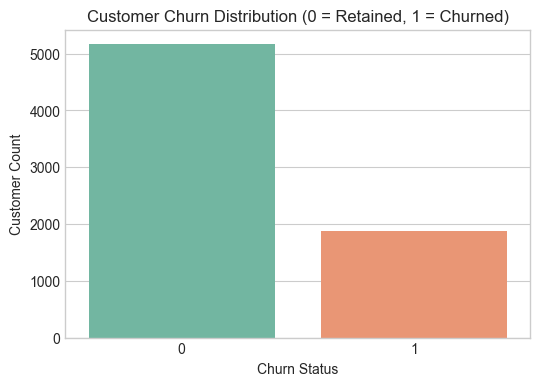

In [73]:
# Set visualization style
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Visualize class imbalance in the target variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution (0 = Retained, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')
plt.show()

### 2.2 Numerical Feature Analysis: Tenure & Monthly Charges

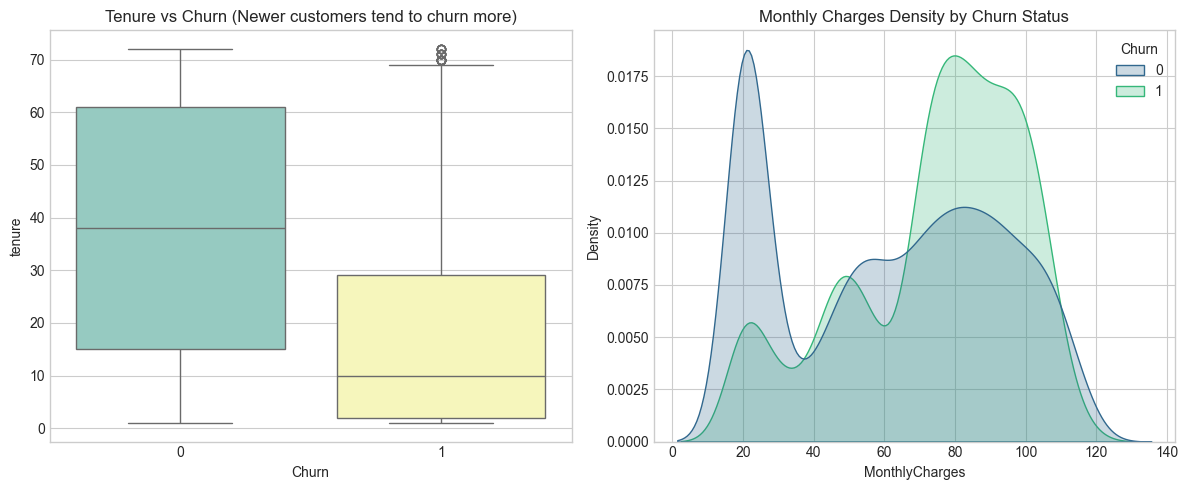

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot examining customer tenure against churn status
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set3', ax=axes[0])
axes[0].set_title('Tenure vs Churn (Newer customers tend to churn more)')

# KDE plot evaluating monthly charges distribution across churned vs retained groups
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='viridis', ax=axes[1])
axes[1].set_title('Monthly Charges Density by Churn Status')

plt.tight_layout()
plt.show()

### 2.3 Categorical Feature Analysis: Contract & Internet Services

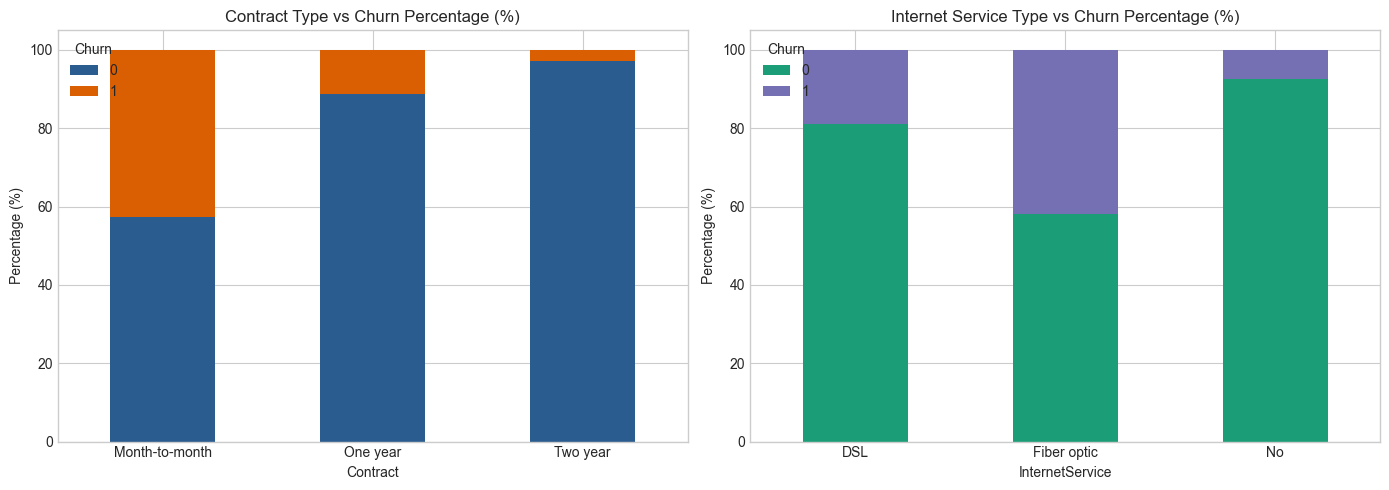

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar plot showing churn percentage across contract types
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['#2b5c8f', '#d95f02'], ax=axes[0])
axes[0].set_title('Contract Type vs Churn Percentage (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)

# Stacked bar plot showing churn percentage across internet service types
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', stacked=True, color=['#1b9e77', '#7570b3'], ax=axes[1])
axes[1].set_title('Internet Service Type vs Churn Percentage (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Phase 3: Feature Engineering & Preprocessing Pipeline
**Objective:** Engineer high-value predictive composite features, partition data via a stratified 70:30 split, and configure a secure preprocessing pipeline incorporating SMOTE to manage class imbalance without data leakage.

### 3.1 Advanced Feature Engineering 

In [76]:
# Feature 1: Average Monthly Charge relative to Tenure (safely handles division by zero using tenure + 1)
df['AvgChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: Total number of active value-added services subscribed by the customer
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['TotalServices'] = df[service_cols].apply(
    lambda x: sum(1 for val in x if val not in ['No service', 'No', 0, 'No internet service']), 
    axis=1
)

# Feature 3: Cost efficiency ratio (Monthly charges per active service)
df['ChargesPerService'] = df['MonthlyCharges'] / (df['TotalServices'] + 1)

# Feature 4: Tenure Cohort Bins (capturing high early churn risk)
def tenure_bucket(tenure):
    if tenure <= 12:
        return '0-1 Year'
    elif tenure <= 24:
        return '1-2 Years'
    elif tenure <= 48:
        return '2-4 Years'
    else:
        return '4+ Years'

df['TenureGroup'] = df['tenure'].apply(tenure_bucket)

# [KAGGLE PRO-FEATURE]: High-Risk Interaction Feature (Contract + Payment Method)
df['Contract_Payment'] = df['Contract'] + "_" + df['PaymentMethod']

print("Advanced features engineered successfully, including 'Contract_Payment'.")

Advanced features engineered successfully, including 'Contract_Payment'.


### 3.2 Stratified Train/Test Split (70:30 Ratio)

In [77]:
from sklearn.model_selection import train_test_split

# Separate feature matrix (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Perform a 70:30 train-test split, stratifying by target to preserve class imbalance ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (4922, 24)
Testing set shape: (2110, 24)


### 3.3 Building the Preprocessing Transformer & SMOTE Pipeline

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical features dynamically from the training subset
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

# Build a ColumnTransformer to apply standard scaling to numerical features and one-hot encoding to categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("Identified Numerical Features:", numeric_features)
print("Total Categorical Features:", len(categorical_features))

Identified Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerTenure', 'TotalServices', 'ChargesPerService']
Total Categorical Features: 17


## Phase 4: Model Development & Hyperparameter Tuning
**Objective:** Train and benchmark multiple baseline classifiers (Logistic Regression, Decision Tree, Random Forest, XGBoost) using SMOTE pipelines, followed by hyperparameter optimization via GridSearchCV.

### 4.1 Training Baseline Models (with SMOTE) & Native Weighted XGBoost

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

# 1. Train standard baseline models using SMOTE pipelines
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost (SMOTE)": XGBClassifier(eval_metric='logloss', random_state=42)
}

trained_pipelines = {}
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    print(f"Successfully trained baseline model: {name}")

# 2. Train Native Weighted XGBoost (Strategy 2: No SMOTE, using scale_pos_weight)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

xgb_native_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_native_pipeline.fit(X_train, y_train)
print("Successfully trained Native Weighted XGBoost model.")

Successfully trained baseline model: Logistic Regression
Successfully trained baseline model: Decision Tree
Successfully trained baseline model: Random Forest
Successfully trained baseline model: XGBoost (SMOTE)
Successfully trained Native Weighted XGBoost model.


### 4.2 Expanded Hyperparameter Optimization for XGBoost

In [80]:
from sklearn.model_selection import GridSearchCV

# Setup optimization pipeline targeting expanded XGBoost parameters to prevent overfitting
xgb_tuning_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Expanded search space including stochastic subsampling and regularization parameters
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [4, 6],
    'classifier__learning_rate': [0.03, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Execute grid search with 3-fold cross-validation maximizing F1 score
grid_search = GridSearchCV(xgb_tuning_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_tuned_model = grid_search.best_estimator_
print("Best Hyperparameters Found for XGBoost:", grid_search.best_params_)

Best Hyperparameters Found for XGBoost: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


## Phase 5: Model Evaluation & Business Perspective
**Objective:** Evaluate models on the unseen test dataset using standard performance metrics and interpret results through a business risk and retention lens.

### 5.1 Comprehensive Model Leaderboard & Evaluation (SMOTE vs. Native Weights)

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve

evaluation_results = []

# Evaluate SMOTE-based baseline models
for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Evaluate Native Weighted XGBoost
y_pred_native = xgb_native_pipeline.predict(X_test)
evaluation_results.append({
    "Model": "XGBoost (Native Class Weights)",
    "Accuracy": accuracy_score(y_test, y_pred_native),
    "Precision": precision_score(y_test, y_pred_native),
    "Recall": recall_score(y_test, y_pred_native),
    "F1 Score": f1_score(y_test, y_pred_native)
})

# Compile and display leaderboard table comparing both methodologies
results_df = pd.DataFrame(evaluation_results).sort_values(by="F1 Score", ascending=False)
display(results_df)

# Designate final production pipeline based on top performer
final_pipeline = xgb_native_pipeline if f1_score(y_test, y_pred_native) > f1_score(y_test, trained_pipelines["XGBoost (SMOTE)"].predict(X_test)) else trained_pipelines["XGBoost (SMOTE)"]

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.741706,0.509324,0.778966,0.615927
4,XGBoost (Native Class Weights),0.772512,0.561086,0.663102,0.607843
3,XGBoost (SMOTE),0.779147,0.584369,0.586453,0.585409
2,Random Forest,0.770616,0.571963,0.545455,0.558394
1,Decision Tree,0.733175,0.498361,0.541889,0.519214


### 5.2 Business Decision Rationale: Precision vs. Recall
For a telecommunications retention team, **Recall** is prioritized over Precision because:
1. **Cost of False Negatives (Missing a Churner):** If our model fails to identify a customer about to churn, the company permanently loses subscription revenue and incurs high customer acquisition replacement costs.
2. **Cost of False Positives (Incorrectly Flagging Loyal Customers):** Offering retention incentives (such as discounts or promotional upgrades) to a loyal customer carries a minimal promotional cost.
Therefore, maximizing **Recall** ensures retention teams capture as many potential churners as possible, making aggressive engagement far safer than missing defecting customers.

## Phase 6: Model Interpretation
**Objective:** Extract feature importances to uncover the primary factors driving customer churn predictions.

### 6.1 Extracting Feature Importances

In [81]:
# Retrieve expanded feature names generated by OneHotEncoder for categorical attributes
cat_encoder = final_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
all_features = numeric_features + encoded_cat_features

# Extract normalized feature importance values from the final trained classifier
importances = final_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

print("Top 10 Features Driving Churn Predictions:")
display(feature_imp_df)

Top 10 Features Driving Churn Predictions:


,Feature,Importance
39,Contract_Month-to-month,0.452138
20,InternetService_No,0.065023
18,InternetService_DSL,0.031360
58,Contract_Payment_One year_Electronic check,0.021391
41,Contract_Two year,0.021375
21,OnlineSecurity_No,0.016237
30,TechSupport_No,0.015689
59,Contract_Payment_One year_Mailed check,0.015445
61,Contract_Payment_Two year_Credit card (automatic),0.015352
38,StreamingMovies_Yes,0.014788


### 6.2 Visualizing Top Churn Drivers

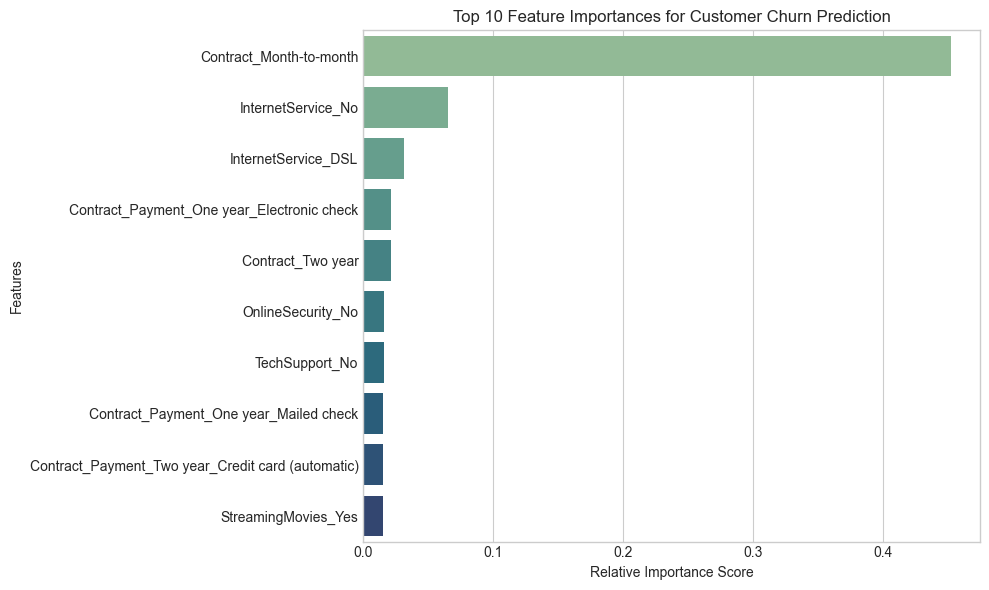

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='crest')
plt.title('Top 10 Feature Importances for Customer Churn Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Phase 7: Model Export & Serialization
**Objective:** Serialize our best-performing trained model pipeline using `joblib` so it can be integrated directly into a production API backend.

In [83]:
import joblib
import os

# Ensure a 'model' directory exists in your root project folder
os.makedirs('../model', exist_ok=True)
model_path = 'model/churn_model.pkl'

# Save your best model pipeline (e.g., xgb_native_pipeline or logistic regression)
# Here we save our top-performing native weighted XGBoost model:
joblib.dump(xgb_native_pipeline, model_path)
print(f"Model successfully saved to: {model_path}")

Model successfully saved to: model/churn_model.pkl
